In [1]:
import pandas as pd
import numpy as np
import ast
import warnings
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, MultiLabelBinarizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score, davies_bouldin_score
from scipy.sparse import hstack, issparse

warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv(r"C:\Users\Admin\Downloads\movies_metadata.csv")

In [3]:
df.shape

(45466, 24)

In [4]:
df.head()

,adult,belongs_to_collection,budget,genres,homepage,id,imdb_id,original_language,original_title,overview,...,release_date,revenue,runtime,spoken_languages,status,tagline,title,video,vote_average,vote_count
0,FALSE,"{'id': 10194, 'name': 'Toy Story Collection', ...",30000000,"[{'id': 16, 'name': 'Animation'}, {'id': 35, '...",http://toystory.disney.com/toy-story,862,tt0114709,en,Toy Story,"Led by Woody, Andy's toys live happily in his ...",...,10/30/1995,373554033.0,81.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,NaN,Toy Story,False,7.7,5415.0
1,FALSE,NaN,65000000,"[{'id': 12, 'name': 'Adventure'}, {'id': 14, '...",NaN,8844,tt0113497,en,Jumanji,When siblings Judy and Peter discover an encha...,...,12/15/1995,262797249.0,104.0,"[{'iso_639_1': 'en', 'name': 'English'}, {'iso...",Released,Roll the dice and unleash the excitement!,Jumanji,False,6.9,2413.0
2,FALSE,"{'id': 119050, 'name': 'Grumpy Old Men Collect...",0,"[{'id': 10749, 'name': 'Romance'}, {'id': 35, ...",NaN,15602,tt0113228,en,Grumpier Old Men,A family wedding reignites the ancient feud be...,...,12/22/1995,0.0,101.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Still Yelling. Still Fighting. Still Ready for...,Grumpier Old Men,False,6.5,92.0
3,FALSE,NaN,16000000,"[{'id': 35, 'name': 'Comedy'}, {'id': 18, 'nam...",NaN,31357,tt0114885,en,Waiting to Exhale,"Cheated on, mistreated and stepped on, the wom...",...,12/22/1995,81452156.0,127.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Friends are the people who let you be yourself...,Waiting to Exhale,False,6.1,34.0
4,FALSE,"{'id': 96871, 'name': 'Father of the Bride Col...",0,"[{'id': 35, 'name': 'Comedy'}]",NaN,11862,tt0113041,en,Father of the Bride Part II,Just when George Banks has recovered from his ...,...,2/10/1995,76578911.0,106.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Just When His World Is Back To Normal... He's ...,Father of the Bride Part II,False,5.7,173.0


In [5]:
df.describe()

,revenue,runtime,vote_average,vote_count
count,4.546000e+04,45203.000000,45460.000000,45460.000000
mean,1.120935e+07,94.128199,5.618207,109.897338
std,6.433225e+07,38.407810,1.924216,491.310374
min,0.000000e+00,0.000000,0.000000,0.000000
25%,0.000000e+00,85.000000,5.000000,3.000000
50%,0.000000e+00,95.000000,6.000000,10.000000
75%,0.000000e+00,107.000000,6.800000,34.000000
max,2.787965e+09,1256.000000,10.000000,14075.000000


In [6]:
df.duplicated().sum()

np.int64(13)

In [7]:
df.drop_duplicates(inplace=True)

In [8]:
# dropping the unnecessary columns
# 1- belongs_to_collection , homepage , tagline were having to many nan values
# the original_title was duplicated with the title
# the spoken_languages was redundant with the original_language
# the poster_path was all paths so we could not use it in the model
df.drop(["belongs_to_collection", "homepage", "original_title","tagline", "id", "imdb_id", "spoken_languages", "poster_path"],axis=1, inplace=True)

In [9]:
df.isnull().sum() / len(df)

adult                   0.000000
budget                  0.000000
genres                  0.000000
original_language       0.000242
overview                0.020989
popularity              0.000110
production_companies    0.000066
production_countries    0.000066
release_date            0.001914
revenue                 0.000132
runtime                 0.005786
status                  0.001914
title                   0.000132
video                   0.000132
vote_average            0.000132
vote_count              0.000132
dtype: float64

In [10]:
#to get the unique values for the columns
# to understand if there is any irrelivant data in the columns or not

for col in ["video", "adult", "status"]:
    print(f"{col} unique values: {df[col].unique()}\n")

video unique values: [False True nan]

adult unique values: ['FALSE' 'TRUE' ' - Written by Ørnås'
 ' Rune Balot goes to a casino connected to the October corporation to try to wrap up her case once and for all.'
 ' Avalanche Sharks tells the story of a bikini contest that turns into a horrifying affair when it is hit by a shark avalanche.']

status unique values: ['Released' nan 'Rumored' 'Post Production' 'In Production' 'Planned'
 'Canceled']



In [11]:
df["budget"] = pd.to_numeric(df["budget"], errors="coerce")
df["revenue"] = pd.to_numeric(df["revenue"], errors="coerce")
df["runtime"] = pd.to_numeric(df["runtime"], errors="coerce")
df["vote_average"] = pd.to_numeric(df["vote_average"], errors="coerce")
df["vote_count"] = pd.to_numeric(df["vote_count"], errors="coerce")
df["popularity"] = pd.to_numeric(df["popularity"], errors="coerce")

In [12]:
 #We apply lowercase ONLY to object (string) columns
# NOT to numeric columns — this avoids the corruption bug

string_cols = df.select_dtypes(include=["object"]).columns
print("String columns to lowercase:", string_cols.tolist())

for col in string_cols:
    df[col] = df[col].apply(lambda s: s.lower() if isinstance(s, str) else s)

String columns to lowercase: ['adult', 'genres', 'original_language', 'overview', 'production_companies', 'production_countries', 'release_date', 'status', 'title', 'video']


In [13]:
# adult column = true , false , nan and other components do not relate to the column

com = [
    ' - Written by Ørnås',
    ' Rune Balot goes to a casino...',
    ' Avalanche Sharks tells the story of a bikini contest...'
]


In [14]:
# to replace the irrelevant data in the adult column with mode values
mode_adult = df["adult"].mode()[0]
df["adult"] = df["adult"].replace(com, mode_adult)
df["adult"] = (df["adult"] == "true").astype(int)

In [15]:
df = df.dropna(subset=["budget"])

In [16]:
df["budget"]  = df["budget"].replace(0, np.nan)
df["revenue"] = df["revenue"].replace(0, np.nan)

In [17]:
mean_budget  = df["budget"].mean()
mean_revenue = df["revenue"].mean()

In [18]:
df["budget"]  = df["budget"].fillna(mean_budget)
df["revenue"] = df["revenue"].fillna(mean_revenue)

In [19]:
df["budget"].isnull().sum()

np.int64(0)

In [20]:
df["budget"].isnull().sum()

np.int64(0)

In [21]:
#Cap extreme outliers BEFORE imputing 
df.loc[df["runtime"] > 400, "runtime"] = np.nan

#Fill NaN with median
median_runtime = df["runtime"].median()
df["runtime"]  = df["runtime"].fillna(median_runtime)


In [22]:
df["status"].unique()

array(['released', nan, 'rumored', 'post production', 'in production',
       'planned', 'canceled'], dtype=object)

In [23]:
df["status"] = df["status"].fillna(df["status"].mode()[0])

In [24]:
status_map = {
    "released":       3,
    "post production": 2,
    "in production":  1,
    "planned":        0,
    "rumored":        0,
    "canceled":       -1
}
df["status_encoded"] = df["status"].map(status_map).fillna(0).astype(int)

In [25]:
df["status_encoded"].value_counts()

status_encoded
 3    45086
 0      244
 2       98
 1       20
-1        2
Name: count, dtype: int64

In [26]:
df["release_date"] = pd.to_datetime(df["release_date"], errors="coerce")
df["year"]         = df["release_date"].dt.year
df = df.dropna(subset=["year"])
df["year"] = df["year"].astype(int)
df.drop("release_date", axis=1, inplace=True)

In [27]:
cols_to_drop = [c for c in ["vote_count", "popularity"] if c in df.columns]
df.drop(cols_to_drop, axis=1, inplace=True)

In [28]:
numeric_cols_expected = ["budget", "revenue", "runtime",
                         "vote_average", "year", "is_english",
                         "adult", "status_encoded"]

numeric_cols_expected = [c for c in numeric_cols_expected if c in df.columns]

df[numeric_cols_expected].dtypes

df[numeric_cols_expected].describe().round(2)
df[numeric_cols_expected].isnull().sum()

# If any NaNs remain — fill with median as safety net
for col in numeric_cols_expected:
    if df[col].isnull().sum() > 0:
        fill_val = df[col].median()
        df[col] = df[col].fillna(fill_val)
        print(f"  Filled {col} NaNs with median: {fill_val}")

In [29]:
mlb_genres = MultiLabelBinarizer()
genres_encoded = pd.DataFrame(
    mlb_genres.fit_transform(df["genres"]),
    columns=[f"genre_{g.replace(' ', '_')}" for g in mlb_genres.classes_],
    index=df.index
)

In [30]:
mlb_companies = MultiLabelBinarizer()
companies_encoded = pd.DataFrame(
    mlb_companies.fit_transform(df["production_companies"]),
    columns=[f"company_{c.replace(' ', '_')}" for c in mlb_companies.classes_],
    index=df.index
)

In [31]:
mlb_countries = MultiLabelBinarizer()
countries_encoded = pd.DataFrame(
    mlb_countries.fit_transform(df["production_countries"]),
    columns=[f"country_{c.replace(' ', '_')}" for c in mlb_countries.classes_],
    index=df.index
)

In [32]:
tfidf = TfidfVectorizer(max_features=150, stop_words="english")

overview_matrix = tfidf.fit_transform(df["overview"].fillna(""))

overview_df = pd.DataFrame(
    overview_matrix.toarray(),
    columns=[f"tfidf_{w}" for w in tfidf.get_feature_names_out()],
    index=df.index
)

In [33]:
X = pd.concat([
    df[numeric_cols_expected],
    genres_encoded,
    countries_encoded,
    companies_encoded,
    overview_df
], axis=1)

In [34]:
# Ensure column names are all strings
X.columns = X.columns.astype(str)

In [35]:
# Remove any duplicate columns
X = X.loc[:, ~X.columns.duplicated()]

In [36]:
X = X.fillna(0)

In [37]:
X.isnull().sum()

budget          0
revenue         0
runtime         0
vote_average    0
year            0
               ..
tfidf_world     0
tfidf_year      0
tfidf_years     0
tfidf_york      0
tfidf_young     0
Length: 468, dtype: int64

In [38]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [39]:
pca_full = PCA(random_state=42)
pca_full.fit(X_scaled)


PCA(random_state=42)

In [40]:
cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)

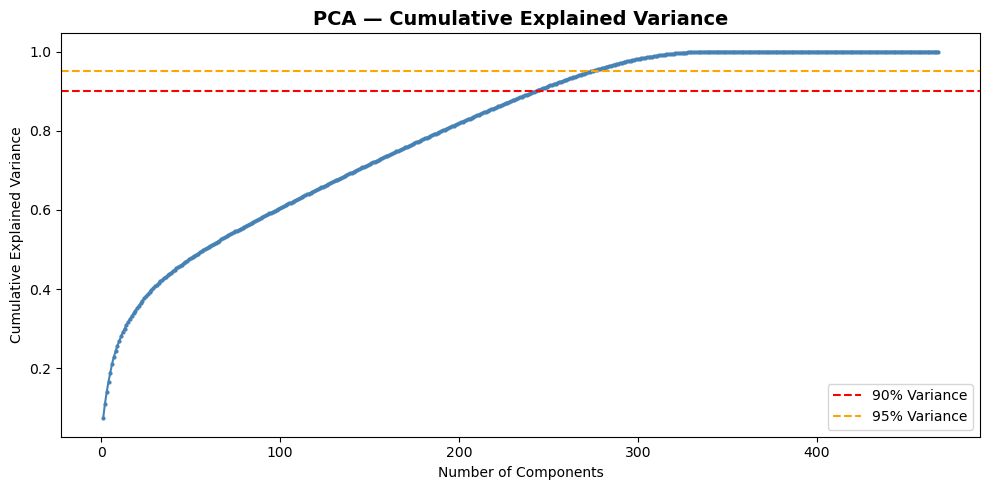

In [41]:
plt.figure(figsize=(10, 5))
plt.plot(range(1, len(cumulative_variance) + 1),
         cumulative_variance, marker='o', markersize=2, color='steelblue')
plt.axhline(y=0.90, color='red',    linestyle='--', label='90% Variance')
plt.axhline(y=0.95, color='orange', linestyle='--', label='95% Variance')
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA — Cumulative Explained Variance", fontsize=14, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

In [42]:
n_components_90 = np.argmax(cumulative_variance >= 0.90) + 1
print(f"Components needed for 90% variance: {n_components_90}")

# Apply PCA
pca = PCA(n_components=n_components_90, random_state=42)
X_pca = pca.fit_transform(X_scaled)

Components needed for 90% variance: 243


In [43]:
inertia_values    = []
silhouette_values = []
db_values         = []
k_range = range(2, 12)


In [44]:
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_pca)
    inertia_values.append(km.inertia_)
    silhouette_values.append(silhouette_score(X_pca, labels))
    db_values.append(davies_bouldin_score(X_pca, labels))
    print(f"  K={k:2d} | Inertia: {km.inertia_:,.0f} | "
          f"Silhouette: {silhouette_score(X_pca, labels):.4f} | "
          f"DB: {davies_bouldin_score(X_pca, labels):.4f}")

  File "c:\ProgramData\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "c:\ProgramData\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "c:\ProgramData\anaconda3\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
                        pass_fds, cwd, env,
                        ^^^^^^^^^^^^^^^^^^^
    ...<5 lines>...
                        gid, gids, uid, umask,
                        ^^^^^^^^^^^^^^^^^^^^^^
                        start_new_session, process_group)
                        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\ProgramData\anaconda3\Lib\subprocess.

  K= 2 | Inertia: 17,589,152 | Silhouette: 0.1170 | DB: 2.5783
  K= 3 | Inertia: 17,078,363 | Silhouette: 0.1040 | DB: 2.3030
  K= 4 | Inertia: 16,701,928 | Silhouette: 0.1335 | DB: 2.4396
  K= 5 | Inertia: 16,258,590 | Silhouette: 0.0726 | DB: 1.8418
  K= 6 | Inertia: 15,731,511 | Silhouette: 0.0580 | DB: 3.3411
  K= 7 | Inertia: 15,621,681 | Silhouette: 0.0537 | DB: 3.5924
  K= 8 | Inertia: 15,215,075 | Silhouette: 0.0608 | DB: 3.0295
  K= 9 | Inertia: 15,158,890 | Silhouette: 0.0727 | DB: 2.0512
  K=10 | Inertia: 14,812,601 | Silhouette: 0.0523 | DB: 2.6985
  K=11 | Inertia: 14,185,234 | Silhouette: 0.0934 | DB: 1.0508


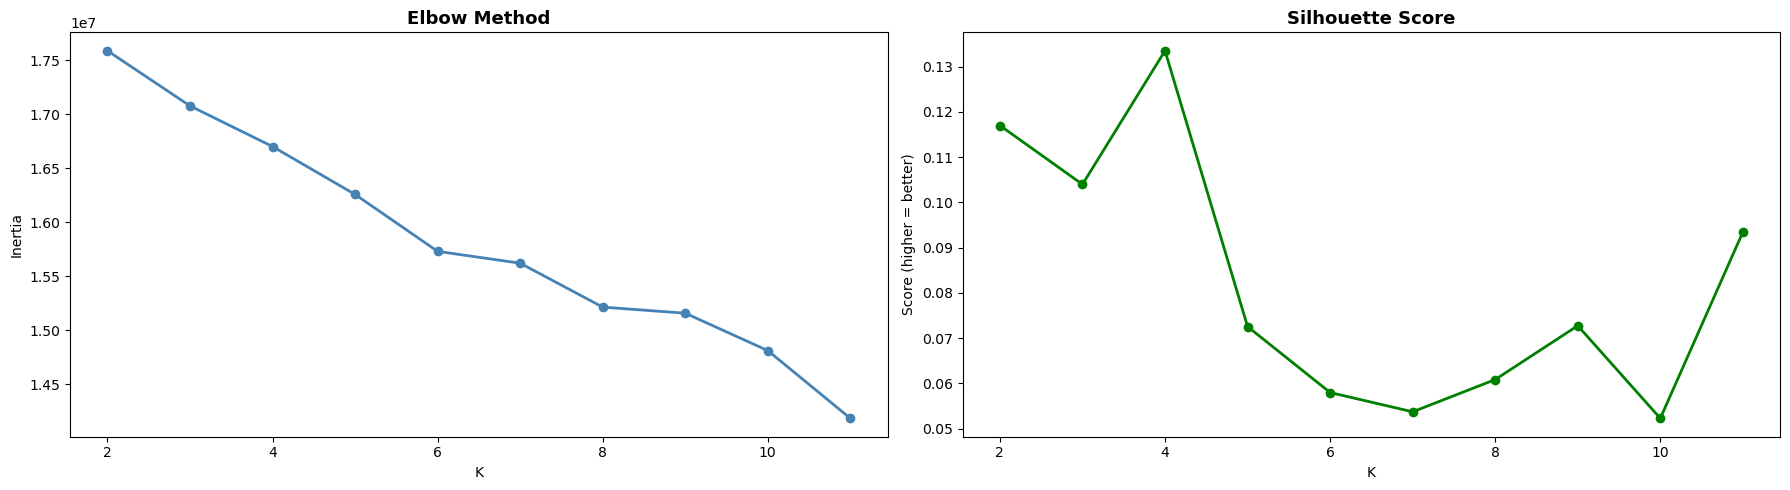

In [55]:
fig, axes = plt.subplots(1, 2, figsize=(18, 5))
axes[0].plot(k_range, inertia_values, marker='o', color='steelblue', linewidth=2)
axes[0].set_title("Elbow Method", fontsize=13, fontweight='bold')
axes[0].set_xlabel("K")
axes[0].set_ylabel("Inertia")

axes[1].plot(k_range, silhouette_values, marker='o', color='green', linewidth=2)
axes[1].set_title("Silhouette Score", fontsize=13, fontweight='bold')
axes[1].set_xlabel("K")
axes[1].set_ylabel("Score (higher = better)")

plt.tight_layout()
plt.show()

In [50]:
best_k = k_range[np.argmax(silhouette_values)]
kmeans_final = KMeans(n_clusters=best_k, random_state=42, n_init=10)
kmeans_labels = kmeans_final.fit_predict(X_pca)
df["kmeans_cluster"] = kmeans_labels
df["kmeans_cluster"].value_counts().sort_index()

kmeans_cluster
0     2362
1     5593
2    32657
3     4670
Name: count, dtype: int64

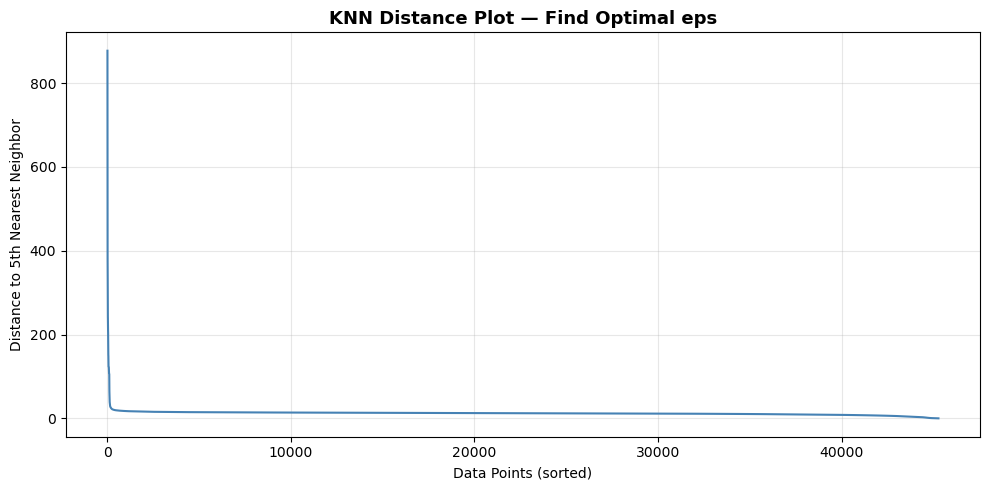

In [51]:
nbrs = NearestNeighbors(n_neighbors=5).fit(X_pca)
distances, _ = nbrs.kneighbors(X_pca)
k_distances = np.sort(distances[:, 4])[::-1]

plt.figure(figsize=(10, 5))
plt.plot(k_distances, color='steelblue')
plt.title("KNN Distance Plot — Find Optimal eps", fontsize=13, fontweight='bold')
plt.xlabel("Data Points (sorted)")
plt.ylabel("Distance to 5th Nearest Neighbor")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [52]:
eps_value = float(input("Enter eps value from the knee of the plot above: "))

In [ ]:
dbscan = DBSCAN(eps=eps_value, min_samples=5, n_jobs=-1)
dbscan_labels = dbscan.fit_predict(X_pca)
df["dbscan_cluster"] = dbscan_labels

n_clusters_db = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise= (dbscan_labels == -1).sum()

In [56]:
n_clusters_db

19

In [57]:
n_noise

np.int64(271)

In [60]:
df.groupby("kmeans_cluster")[[
    "budget",
    "revenue",
    "runtime",
    "vote_average"
]].mean().round(2)

,budget,revenue,runtime,vote_average
kmeans_cluster,,,,
0,21133658.21,68214885.59,70.21,4.29
1,20098973.18,65507521.17,90.19,5.47
2,22049992.65,69700715.44,97.44,5.82
3,20568553.32,66812450.25,84.35,5.10


In [61]:
for c in sorted(df["kmeans_cluster"].unique()):
    
    print(f"\nCluster {c}")
    
    print(
        df[df["kmeans_cluster"]==c]
        [["title","genres","vote_average"]]
        .head(5)
    )


Cluster 0
                           title genres  vote_average
55       kids of the round table     []           3.0
83   last summer in the hamptons     []           0.0
126               jupiter's wife     []           0.0
137                       target     []           0.0
390                 desert winds     []           0.0

Cluster 1
                     title                                             genres  \
52                lamerica  [{'id': 18, 'name': 'drama'}, {'id': 10769, 'n...   
57             the postman  [{'id': 35, 'name': 'comedy'}, {'id': 18, 'nam...   
58        the confessional  [{'id': 53, 'name': 'thriller'}, {'id': 18, 'n...   
104        nobody loves me  [{'id': 18, 'name': 'drama'}, {'id': 35, 'name...   
114  anne frank remembered  [{'id': 99, 'name': 'documentary'}, {'id': 18,...   

     vote_average  
52            7.7  
57            7.6  
58            6.5  
104           5.1  
114           7.3  

Cluster 2
                         title  \
0 

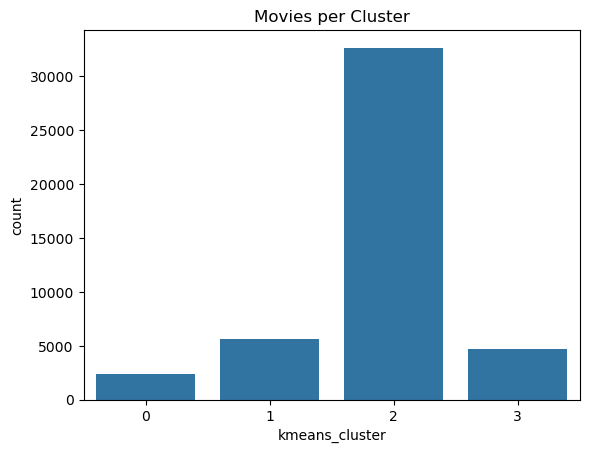

In [62]:
sns.countplot(x=df["kmeans_cluster"])
plt.title("Movies per Cluster")
plt.show()

# The KMeans algorithm identified 4 clusters of movies.

Cluster 0

Movies with missing metadata and very low ratings.

Cluster 1

Drama and artistic films with relatively high ratings.

Cluster 2

Popular mainstream movies with broader audience appeal.

Cluster 3

Mixed-genre niche movies including crime, documentary, and action.

In [64]:
while True:
    print("\n" + "="*50)
    print("🎬 Welcome to Movie Recommendation System")
    print("="*50)
    
    # --- Take input from user ---
    movie_title = input("\nEnter a movie name (or 'quit' to exit): ").strip()
    
    # --- Exit condition ---
    if movie_title.lower() == "quit":
        print("\n👋 Goodbye!")
        break
    
    # --- How many recommendations ---
    try:
        n = int(input("How many recommendations do you want? (default 5): ").strip())
    except ValueError:
        n = 5  # default if user enters nothing or invalid

    # --- Find the movie ---
    match = df[df["title"].str.lower().str.strip() == movie_title.lower().strip()]

    if match.empty:
        print(f"\n❌ Movie '{movie_title}' not found.")
        
        # Show similar titles to help the user
        similar = df[df["title"].str.lower().str.contains(
                    movie_title.lower(), na=False)]["title"].head(5)
        
        if not similar.empty:
            print("\n🔍 Did you mean one of these?")
            for i, t in enumerate(similar, 1):
                print(f"   {i}. {t}")
        continue

    # --- Get cluster ---
    cluster_id = match["kmeans_cluster"].values[0]

    # --- Get movies from same cluster ---
    same_cluster = df[
        (df["kmeans_cluster"] == cluster_id) &
        (df["title"].str.lower().str.strip() != movie_title.lower().strip())
    ]

    # --- Sort by rating ---
    if "vote_average" in df.columns:
        same_cluster = same_cluster.sort_values("vote_average", ascending=False)

    top_movies = same_cluster.head(n)

    # --- Show results ---
    print(f"\n✅ Movie Found    : {match['title'].values[0]}")
    print(f"📦 Cluster Number : {cluster_id}")
    print(f"📊 Cluster Size   : {len(same_cluster) + 1} movies")
    print(f"\n{'='*50}")
    print(f"🎬 Because you watched '{match['title'].values[0]}' :")
    print(f"{'='*50}")

    for i, row in enumerate(top_movies.itertuples(), 1):
        title   = row.title
        rating  = row.vote_average if "vote_average" in df.columns else "N/A"
        year    = row.year         if "year"         in df.columns else "N/A"
        print(f"   {i}. {title:<40} ⭐ {rating}   📅 {year}")

    print("\n" + "="*50)
    again = input("🔄 Search another movie? (yes/no): ").strip().lower()
    if again != "yes":
        print("\n👋 Goodbye!")
        break



🎬 Welcome to Movie Recommendation System

❌ Movie 'toy store' not found.

🎬 Welcome to Movie Recommendation System

✅ Movie Found    : toy story
📦 Cluster Number : 2
📊 Cluster Size   : 32657 movies

🎬 Because you watched 'toy story' :
   1. common threads: stories from the quilt   ⭐ 10.0   📅 1989
   2. lego dc super hero girls: brain drain    ⭐ 10.0   📅 2017
   3. one man's journey                        ⭐ 10.0   📅 1933
   4. tokyo ghoul                              ⭐ 10.0   📅 2017
   5. growing pains                            ⭐ 10.0   📅 1984


👋 Goodbye!
